## Análisis de datos - Clase 2

## Introducción al EDA: medidas estadísticas descriptivas 
<hr style="border:1px solid gray">

In [10]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe


#### Funciones auxiliares (helper functions)



In [1]:
def load_dataset():
    return

In [2]:
# Función para graficar
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, shade=True, snk=False):
    skewness = (data[column]).skew()
    kurtosis = (data[column]).kurt()
    media = (data[column]).mean()
    var = (data[column]).var()
    std = (data[column]).std()
    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde)
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
        plt.axvline(media, color='red', linestyle='--', label='Media')
 

    # Sombreado
    if mvd and shade:
        plt.axvspan(media - std, media + std, alpha=0.1, color='orange', label='±1 Std')
        plt.axvline(media + std, color='orange', linestyle=':', label='+1 Std')
        plt.axvline(media - std, color='orange', linestyle=':', label='-1 Std')
        plt.figtext(0.15, 0.80, f'Media: {media:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.73, f'Var:   {var:.2f}',   fontsize=10, color='red')
        plt.figtext(0.15, 0.66, f'Std:   {std:.2f}',   fontsize=10, color='orange')

    

    plt.title(f'Variable: {column}')
    plt.xlabel(f'{column}')
    plt.ylabel('Frecuencia')
    plt.show()
    
    return

In [3]:
def cuartiles(variable):
    Q1 = variable.quantile(0.25)
    Q2 = variable.quantile(0.50)  # Percentile 5-0 - Equivalente a la mediana
    Q3 = variable.quantile(0.75)
    return Q1, Q2, Q3

In [4]:
def print_categorias(dataframe, columna):
    print(f"Cantidad de categorías que tiene la variable '{columna}': {dataframe[columna].nunique()}\n")
    print(f"Nombres de categorías presentes en la variable '{columna}': {dataframe[columna].unique()}\n")
    
    freq = dataframe[columna].value_counts()
    freq_rel = dataframe[columna].value_counts(normalize=True).mul(100).round(2)
    
    freq_tabla = pd.DataFrame({'Frecuencia absoluta': freq, 'Frecuencia relativa (%)': freq_rel})
    
    print(f"Frecuencias de cada categoría en la variable '{columna}':\n{freq_tabla}\n")

In [5]:
def plot_pie(data, column, ax=None, startangle=90, palette='pastel', title=None):
    counts = data[column].value_counts()
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    
    ax.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=startangle,
        colors=sns.color_palette(palette)
    )
    ax.set_title(title if title else f'Distribución de "{column}"')
    ax.axis('equal') # Asegura que el gráfico sea circular

In [6]:
def plot_frecuencias_relativas(data, column, ax=None, palette='viridis', figsize=(9, 4), title=None):
    total = len(data)
    relative_freq = data[column].value_counts() / total

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(x=relative_freq.values, y=relative_freq.index, hue=relative_freq.index, 
                palette=palette, ax=ax, legend=False)
    
    ax.set_title(title if title else f'Frecuencias relativas de {column}')
    ax.set_xlabel('Frecuencia relativa')
    ax.set_ylabel(column)

plt.show()

In [7]:
def plot_violin_box(data, num_col, cat_col, figsize=(12, 4), palette='pastel', title=None):
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    # Violin plot
    sns.violinplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                   palette=palette, ax=axes[0], legend=False)
    axes[0].set_title(f'Violin: {num_col} vs. {cat_col}')
    axes[0].grid(axis='y', ls='--')

    # Box plot
    sns.boxplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                palette=palette, ax=axes[1], legend=False)
    axes[1].set_title(f'Boxplot: {num_col} vs. {cat_col}')
    axes[1].grid(axis='y', ls='--')

    plt.suptitle(title if title else f'{num_col} vs {cat_col}', fontsize=13)
    plt.tight_layout()
    plt.show()


#### Descripción del dataset Recorridos Ecobicis


| Variable      | Descripción                                                                      |
| ------------- | ---------------------------------------------------------------------------------- |
| `id_recorrido`| id del recorrido                                                  |
| `duracion_recorrido` | Duración del recorrido en segundos                                                      |
| `fecha_origen_recorrido`  | Fecha de origen (timestamp)                                               |
| `id_estacion_origen`      | id estacion de origen                                                        |
| `nombre_estacion_origen`  | Nombre estacion de origen                                              |
| `direccion_estacion_origen`       | Direccion estacion de origen                                                   |
| `long_estacion_origen`        | Longitud ubicacion estacion de origen                                                        |
| `lat_estacion_origen`    | Longuitud estacion de origen          |
| `fecha_destino_recorrido`       | Fecha de origen (timestamp) |
| `id_estacion_destino`         | Id estacion destino  |
| `nombre_estacion_destino`  | Nombre estacion destino                                                    |
| `direccion_estacion_destino`        | Direccion estacion de destino                             |
| `long_estacion_destino` | longitud destino                                               |
| `lat_estacion_destino`       | latitud destino                                                  |
| `id_usuario`       | id de usuario                          |
| `modelo_bicicleta`       | Modelo de bicicleta                          |
| `genero` | Genero del usuario (MALE, FEMALE, OTHER)

#### Importamos el dataset
---


In [40]:
# Cargamos el dataset de Titanic
df = pd.read_csv('dataset/trips_2023.csv', thousands=',') # sns.load_dataset Devuelve un Pandas DF

#### Primera inspección
<hr style="border:1px solid gray">

#### a. Recorridos ecobicis
---

In [41]:
print(f"Dimensiones del dataset original: {df.shape}")

# Drop first column
df = df.drop(columns=['Unnamed: 0'])
df.head()

Dimensiones del dataset original: (2622331, 18)


,Id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,género
0,17910696BAEcobici,1848,2023-04-24 10:30:10,358BAEcobici,249 - Balbín,2519 Conesa,-58.465586,-34.561486,2023-04-24 11:00:58,278BAEcobici,233 - MONROE,2519 Superi,-58.469813,-34.564122,861866BAEcobici,ICONIC,MALE
1,17600256BAEcobici,288,2023-03-22 17:40:55,444BAEcobici,061 - Ministerio de Economia,"Balcarce e Yrigoyen, Hipolito Av.",-58.370716,-34.608936,2023-03-22 17:45:43,3BAEcobici,003 - ADUANA,Moreno & Azopardo,-58.368174,-34.611102,217525BAEcobici,ICONIC,FEMALE
2,17255670BAEcobici,1103,2023-02-15 23:12:22,280BAEcobici,222 - SIMON BOLIVAR,"1701 Fernandez Moreno, Baldomero",-58.449379,-34.633528,2023-02-15 23:30:45,280BAEcobici,222 - SIMON BOLIVAR,"1701 Fernandez Moreno, Baldomero",-58.449379,-34.633528,954201BAEcobici,ICONIC,MALE
3,17996972BAEcobici,1165,2023-05-03 11:00:20,273BAEcobici,223 - GAINZA,"494 Gainza, Martin De, Gral.",-58.446751,-34.616758,2023-05-03 11:19:45,367BAEcobici,287 - Belaustegui,"Belaustegui, Luis, Dr. 2890",-58.477209,-34.616212,179414BAEcobici,ICONIC,MALE
4,17148836BAEcobici,378,2023-02-06 06:50:58,65BAEcobici,065 - Julián Álvarez,3822 Guemes,-58.415787,-34.587312,2023-02-06 06:57:16,14BAEcobici,014 - Pacifico,"Santa Fe Av. & Bullrich, Int. Av.",-58.426387,-34.577424,8098BAEcobici,ICONIC,MALE


In [51]:
# rename duracion_recorrido
df = df.rename(columns={'duracion_recorrido':'duracion_recorrido_seg', 'género':'genero'})


In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2622331 entries, 0 to 2622330
Data columns (total 17 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Id_recorrido                str    
 1   duracion_recorrido_seg      int64  
 2   fecha_origen_recorrido      str    
 3   id_estacion_origen          str    
 4   nombre_estacion_origen      str    
 5   direccion_estacion_origen   str    
 6   long_estacion_origen        float64
 7   lat_estacion_origen         float64
 8   fecha_destino_recorrido     str    
 9   id_estacion_destino         str    
 10  nombre_estacion_destino     str    
 11  direccion_estacion_destino  str    
 12  long_estacion_destino       float64
 13  lat_estacion_destino        float64
 14  id_usuario                  str    
 15  modelo_bicicleta            str    
 16  genero                      str    
dtypes: float64(4), int64(1), str(12)
memory usage: 812.4 MB


#### Identificamos y ajustamos los tipos de variables

In [55]:
df = df.astype({
      'Id_recorrido': 'str',
      'duracion_recorrido_seg': 'int64',
      'fecha_origen_recorrido': 'datetime64[ns]',
      'id_estacion_origen': 'str',
      'nombre_estacion_origen': 'str',
      'direccion_estacion_origen': 'str',
      'long_estacion_origen': 'float64',  
      'lat_estacion_origen': 'float64',   
      'fecha_destino_recorrido': 'datetime64[ns]',
      'id_estacion_destino': 'str',
      'nombre_estacion_destino': 'str',
      'direccion_estacion_destino': 'str',
      'long_estacion_destino': 'float64',  
      'lat_estacion_destino': 'float64',   
      'id_usuario': 'str',
      'modelo_bicicleta': 'category',  # limited distinct values
      'genero': 'category'  # limited distinct values (MALE/FEMALE/etc)
  })


---
---
## Estadística descriptiva
---
---

### 1. Exploración de VARIABLES NUMÉRICAS

#### 1.1. Medidas de tendencia central: media, mediana y moda


#### Media

In [76]:
np.mean(df['duracion_recorrido_seg'])/60    # con NumPy

np.float64(23.01022199968908)

In [77]:
mean_recorrido = df['duracion_recorrido_seg'].mean()# con Pandas
print("Duracion media en minutos: ", mean_recorrido/60)

Duracion media en minutos:  23.01022199968908


#### Mediana

In [78]:
np.median(df['duracion_recorrido_seg'])/60 # con NumPy (no funciona con nulos)

np.float64(15.533333333333333)

In [81]:
np.median(df['duracion_recorrido_seg'].dropna())/60 # con NumPy (ignorando nulos)

np.float64(15.533333333333333)

In [82]:
df['duracion_recorrido_seg'].median()    # con Pandas

np.float64(932.0)

#### Moda

#### Moda

In [92]:
df['id_estacion_origen'].mode()     # con Pandas

0    175BAEcobici
Name: id_estacion_origen, dtype: str

In [99]:
df.query('id_estacion_origen == "175BAEcobici"').head(3)

,Id_recorrido,duracion_recorrido_seg,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
35,18349462BAEcobici,1029,2023-06-14 23:54:50,175BAEcobici,147 - Constitución,Avenida Juan de Garay 1050,-58.380707,-34.626851,2023-06-15 00:11:59,83BAEcobici,083 - Paraná,1590 Lavalle,-58.389373,-34.603269,468004BAEcobici,ICONIC,MALE
66,16944587BAEcobici,1176,2023-01-16 19:11:15,175BAEcobici,147 - Constitución,Avenida Juan de Garay 1050,-58.380707,-34.626851,2023-01-16 19:30:51,132BAEcobici,132 - CORRIENTES,Reconquista & Corrientes Av.,-58.372763,-34.603369,1917BAEcobici,ICONIC,FEMALE
131,17155654BAEcobici,2749,2023-02-06 17:34:49,175BAEcobici,147 - Constitución,Avenida Juan de Garay 1050,-58.380707,-34.626851,2023-02-06 18:20:38,449BAEcobici,352 - San Jose de Flores,Av. Rivadavia 6955,-58.463297,-34.628836,29130BAEcobici,ICONIC,FEMALE


# Histogramas

In [166]:
total_recorridos = len(df)
total_unique_users = df['id_usuario'].nunique()
total_unique_stations = df['id_estacion_origen'].nunique()

print(f"Total de recorridos: {total_recorridos:,}")
print(f"Total de usuarios: {total_unique_users:,}")
print(f"Total de estaciones: {total_unique_stations:,}")

Total de recorridos: 2,622,331
Total de usuarios: 212,068
Total de estaciones: 364


### Distribucion por genero

genero
MALE      1580419
FEMALE     790640
OTHER      239306
Name: count, dtype: int64


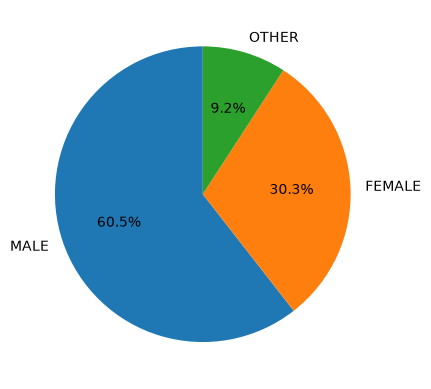

In [108]:
plt.pie(genre_counts, labels=genre_counts.index,autopct='%1.1f%%', startangle=90)

### Duracion recorridos

mean 23.009914842939356
median 16.0
mode 8
skew 207.69187993924396
curtosis 61473.01560807058


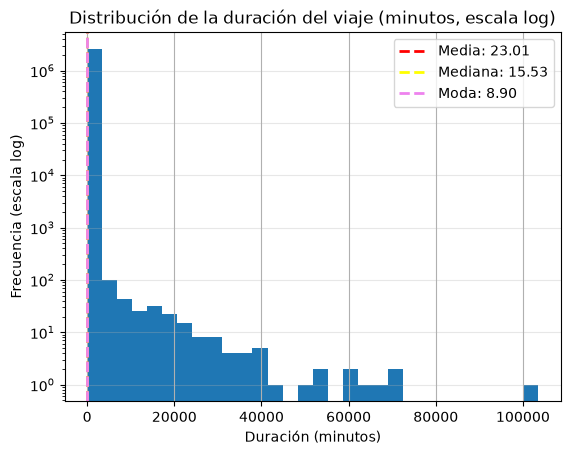

In [162]:
df['duracion_min'] = (df['duracion_recorrido_seg'] / 60).astype(float)

media_duration = df['duracion_min'].mean()
mediana_duration = df['duracion_min'].median()
moda_duration = df['duracion_min'].mode()[0]
skew_duration = df['duracion_min'].skew()
curtosis_duration = df['duracion_min'].kurtosis()

print("mean", mean_duration)
print("median", median_duration)
print("mode", mode_duration)
print("skew", skew_duration)
print("curtosis", curtosis_duration)

df['duracion_min'].hist(bins=30, log=True)
plt.axvline(media_duration, color='red', linestyle='--', linewidth=2, label=f'Media: {media_duration:.2f}')
plt.axvline(mediana_duration, color='yellow', linestyle='--', linewidth=2, label=f'Mediana: {mediana_duration:.2f}')
plt.axvline(mediana_duration, color='violet', linestyle='--', linewidth=2, label=f'Moda: {moda_duration:.2f}')

plt.title('Distribución de la duración del viaje (minutos, escala log)')
plt.xlabel('Duración (minutos)')
plt.ylabel('Frecuencia (escala log)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### Estaciones

Total estaciones:  364
Media: 7204.21
Mediana: 6011.00
Moda: 3692.00


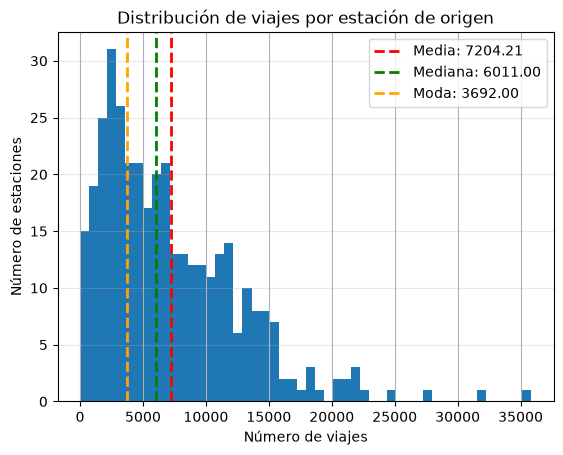

In [163]:
estaciones = df['id_estacion_origen'].value_counts(sort=True)
print("Total estaciones: ", len(estaciones))

mean_val = estaciones.mean()
median_val = estaciones.median()
mode_val = estaciones.mode()[0]

print(f'Media: {mean_val:.2f}')
print(f'Mediana: {median_val:.2f}')
print(f'Moda: {mode_val:.2f}')

estaciones.hist(bins=50)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Mediana: {median_val:.2f}')
plt.axvline(mode_val, color='orange', linestyle='--', linewidth=2, label=f'Moda: {mode_val:.2f}')
plt.title('Distribución de viajes por estación de origen')
plt.xlabel('Número de viajes')
plt.ylabel('Número de estaciones')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [149]:
top_five_estaciones = estaciones.head(5).index

# Get info for those stations
for station_id in top_five_estaciones:
  station_data = df[df['id_estacion_origen'] == station_id].iloc[0]
  trips_count = len(df[df['id_estacion_origen'] == station_id])
  print(f"ID: {station_id}")
  print(f"Nombre: {station_data['nombre_estacion_origen']}")
  print(f"Dirección: {station_data['direccion_estacion_origen']}")
  print(f"Viajes: {trips_count}")
  print("---")


ID: 175BAEcobici
Nombre: 147 - Constitución
Dirección: Avenida Juan de Garay 1050
Viajes: 35834
---
ID: 14BAEcobici
Nombre: 014 - Pacifico
Dirección: Santa Fe Av. & Bullrich, Int. Av.
Viajes: 31698
---
ID: 8BAEcobici
Nombre: 008 - Congreso
Dirección: Cevallos, Virrey& Yrigoyen, Hipolito Av.
Viajes: 27249
---
ID: 5BAEcobici
Nombre: 005 - Plaza Italia
Dirección: Av. Sarmiento 2601
Viajes: 24924
---
ID: 202BAEcobici
Nombre: 001 - FACULTAD DE DERECHO
Dirección: Av. Pres. Figueroa Alcorta 2120
Viajes: 22779
---


In [150]:
print(df.isnull().sum())

Id_recorrido                      0
duracion_recorrido_seg            0
fecha_origen_recorrido            0
id_estacion_origen                0
nombre_estacion_origen            0
direccion_estacion_origen         0
long_estacion_origen              0
lat_estacion_origen               0
fecha_destino_recorrido           0
id_estacion_destino               2
nombre_estacion_destino           2
direccion_estacion_destino        2
long_estacion_destino             2
lat_estacion_destino              2
id_usuario                        0
modelo_bicicleta                  0
genero                        11966
duracion_recorrido_min            0
duracion_min                      0
dtype: int64


#### 1.2. Histogramas 

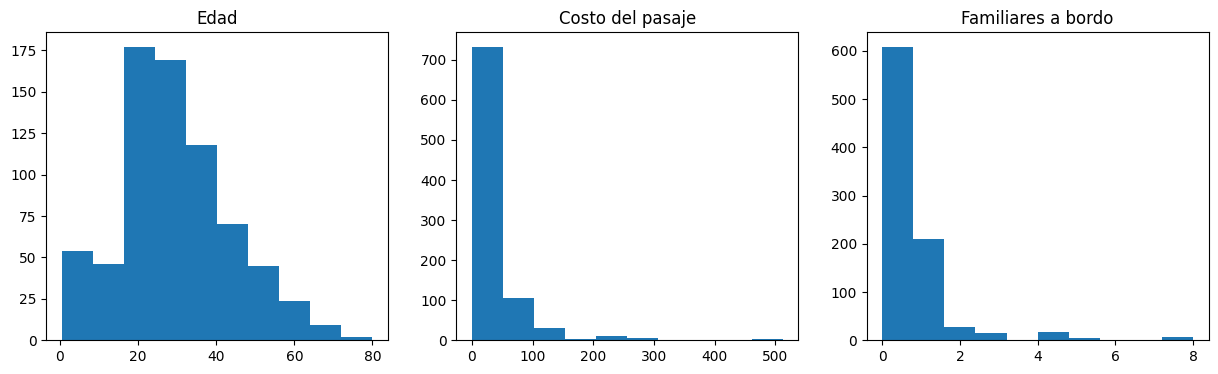

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(titanic_df['age'])   # edad
ax[0].set_title('Edad')
ax[1].hist(titanic_df['fare'])  # costo del pasaje
ax[1].set_title('Costo del pasaje')
ax[2].hist(titanic_df['sibsp']) # familiares
ax[2].set_title('Familiares a bordo')

plt.show()


#### Variantes del histograma de edad

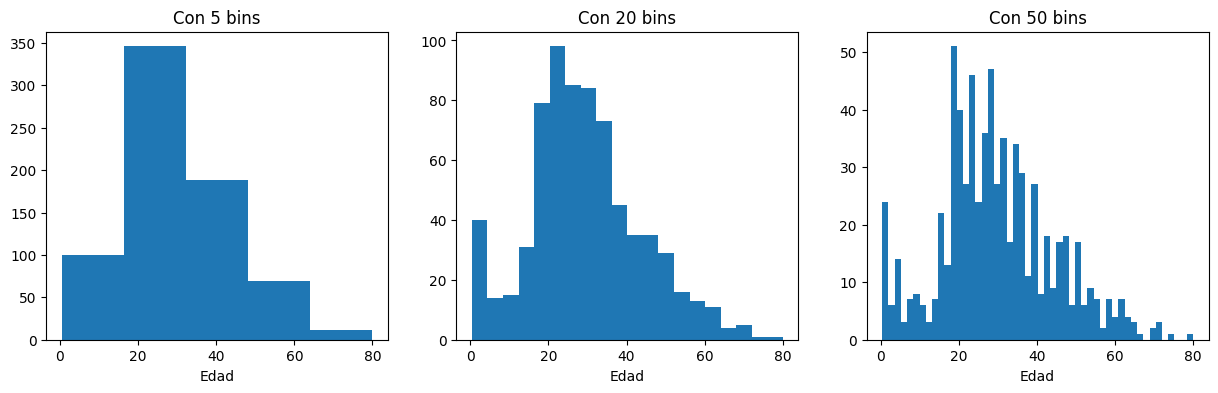

In [22]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(titanic_df['age'], bins=5)
ax[0].set_title('Con 5 bins')
ax[0].set_xlabel('Edad')
ax[1].hist(titanic_df['age'], bins=20)
ax[1].set_title('Con 20 bins')
ax[1].set_xlabel('Edad')
ax[2].hist(titanic_df['age'], bins=50)
ax[2].set_title('Con 50 bins')
ax[2].set_xlabel('Edad')

plt.show()

#### 1.3. Medidas de tendencia central + histograma

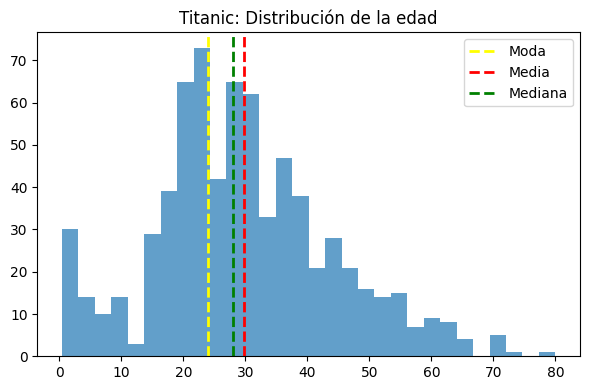

In [23]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(titanic_df['age'], bins=30, alpha=0.7) # dibujar histograma
ax.axvline(titanic_df['age'].mode()[0], color='yellow', ls='--', lw=2, label='Moda')
ax.axvline(titanic_df['age'].mean(), color='red', ls='--', lw=2, label='Media')
ax.axvline(titanic_df['age'].median(), color='green', ls='--', lw=2, label='Mediana')
ax.set_title('Titanic: Distribución de la edad')
ax.legend()

plt.tight_layout()
plt.show()

#### Comparamos la distribución de las tres variables: edad, costo del pasaje y número de familiares

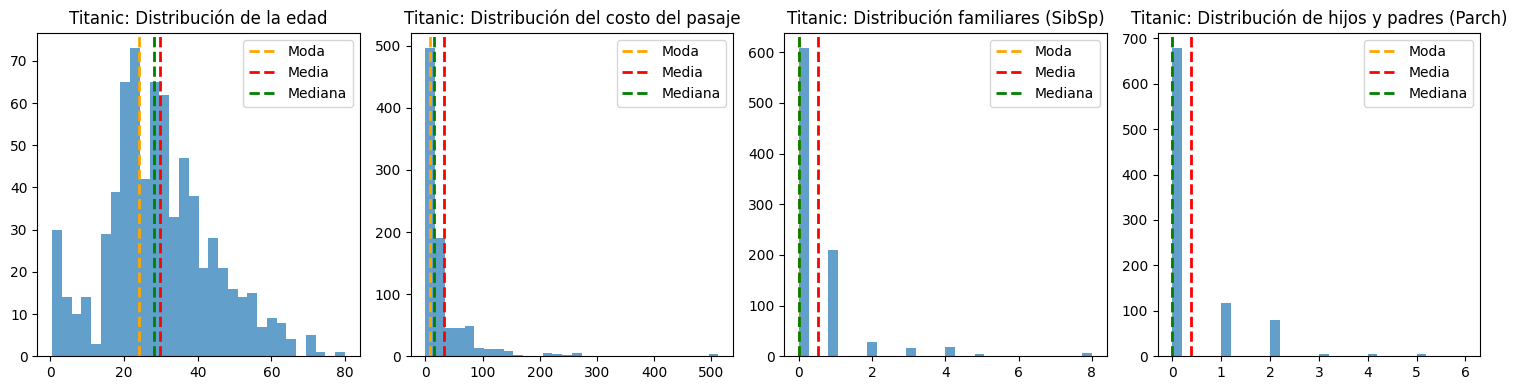

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

# Función para graficar
def plot_distribution(ax, data, title):
    ax.hist(data, bins=30, alpha=0.7) # dibujar histograma
    ax.axvline(data.mode()[0], color='orange', linestyle='dashed', linewidth=2, label='Moda') # dibujar la moda
    ax.axvline(data.mean(), color='red', linestyle='dashed', linewidth=2, label='Media') # dibujar la media
    ax.axvline(data.median(), color='green', linestyle='dashed', linewidth=2, label='Mediana') # dibujar la mediana
    ax.set_title(title)
    ax.legend()

plot_distribution(axes[0], titanic_df['age'], 'Titanic: Distribución de la edad')
plot_distribution(axes[1], titanic_df['fare'], 'Titanic: Distribución del costo del pasaje')
plot_distribution(axes[2], titanic_df['sibsp'], 'Titanic: Distribución familiares (SibSp)')
plot_distribution(axes[3], titanic_df['parch'], 'Titanic: Distribución de hijos y padres (Parch)')

plt.tight_layout()
plt.show()

#### ¿Qué métrica representa mejor cada variable (edad, costo, familiares)?

#### KDE: Kernel Density Estimation --> estimar la función de densidad de probabilidad (PDF)

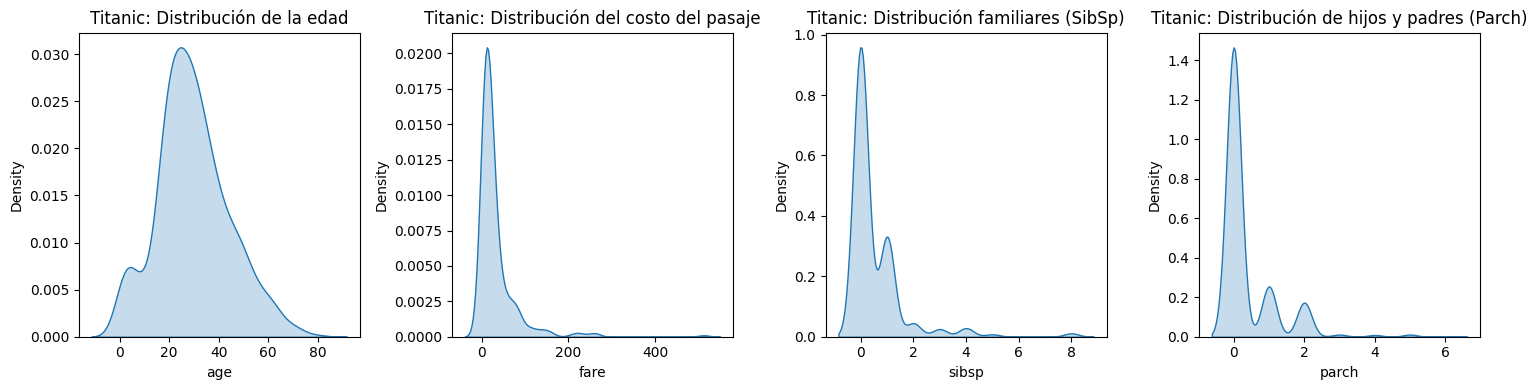

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

sns.kdeplot(data=titanic_df, x='age', fill=True, ax=axes[0])
sns.kdeplot(data=titanic_df, x='fare', fill=True, ax=axes[1])
sns.kdeplot(data=titanic_df, x='sibsp', fill=True, ax=axes[2])
sns.kdeplot(data=titanic_df, x='parch', fill=True, ax=axes[3])
axes[0].set_title('Titanic: Distribución de la edad')
axes[1].set_title('Titanic: Distribución del costo del pasaje')
axes[2].set_title('Titanic: Distribución familiares (SibSp)')
axes[3].set_title('Titanic: Distribución de hijos y padres (Parch)')

plt.tight_layout()
plt.show()

#### Swarmplot

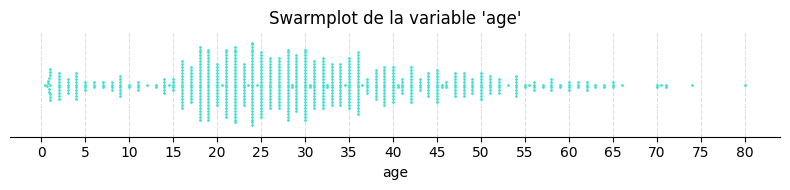

In [26]:
plt.figure(figsize=(8, 2))
sns.swarmplot(x=titanic_df['age'], color='turquoise', size=2)

ax = plt.gca()
ax.set_xticks(np.arange(0, int(titanic_df['age'].max()) + 1, 5))
ax.grid(axis='x', which='major', linestyle='--', alpha=0.4)
ax.set_yticks([])
ax.set_ylabel("")
ax.set_xlabel("age")
sns.despine(left=True)

plt.title(f"Swarmplot de la variable 'age'")
plt.tight_layout()
plt.show()

### 1.4. Medidas de dispersión: varianza y desviación estándar
<hr style="border:1px solid gray">


In [208]:
# Calculamos la media, varianza y desviación estándar del largo de las aletas
age_media = titanic_df['age'].mean()
age_var = titanic_df['age'].var()
age_std_dev = titanic_df['age'].std()
print(f'La media de la edad de los pasajeros es {age_media:.2f} años, \nla varianza es {age_var:.4f} y \nla desviación estándar es {age_std_dev:.4f} años')

La media de la edad de los pasajeros es 29.70 años, 
la varianza es 211.0191 y 
la desviación estándar es 14.5265 años


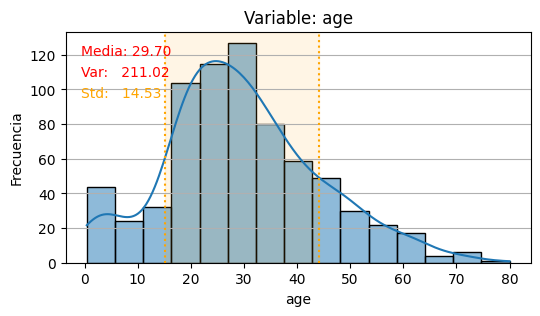

In [27]:
# Usamos la función que definimos para graficar (ver sección HELPER FUNCTIONS)
plot_histograma(titanic_df, 'age')

### 1.5. Cuartiles y rango intercuartil
<hr style="border:1px solid gray">


In [210]:
age_Q1, age_Q2, age_Q3 = cuartiles(titanic_df['age'])

print("Q1 (25%):", age_Q1)
print("Q2 (Mediana, 50%):", age_Q2)
print("Q3 (75%):", age_Q3)

Q1 (25%): 20.125
Q2 (Mediana, 50%): 28.0
Q3 (75%): 38.0


In [211]:
age_IQR = age_Q3 - age_Q1
print("Rango intercuartil (IQR):", age_IQR)

Rango intercuartil (IQR): 17.875


#### Visualizamos con Boxplots

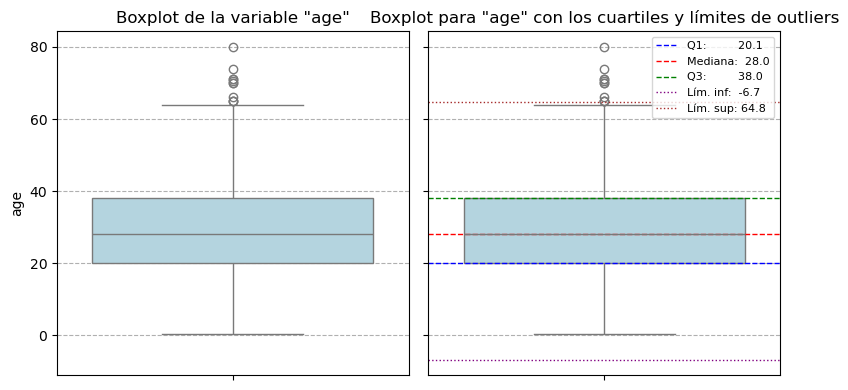

In [212]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

age = titanic_df['age'].dropna()

# Límites teóricos para detectar outliers
lower_limit = age_Q1 - 1.5 * age_IQR
upper_limit = age_Q3 + 1.5 * age_IQR

# ax[0]: Boxplot como viene
sns.boxplot(data=titanic_df, y='age', color="lightblue", ax=ax[0])
#sns.boxplot(data=titanic_df, y='age', color="lightblue", showfliers=False, ax=ax[0]) # En caso que no queramos mostrar los outliers en el boxplot
ax[0].set_title('Boxplot de la variable "age"')
ax[0].grid(axis='y', ls='--')

# ax[1]: Boxplot con detalles
sns.boxplot(data=titanic_df, y='age', color="lightblue", ax=ax[1])
ax[1].axhline(age_Q1,      color='blue',   linestyle='--', linewidth=1, label=f'Q1:         {age_Q1:.1f}')
ax[1].axhline(age_Q2,      color='red',    linestyle='--', linewidth=1, label=f'Mediana:  {age_Q2:.1f}')
ax[1].axhline(age_Q3,      color='green',  linestyle='--', linewidth=1, label=f'Q3:         {age_Q3:.1f}')
ax[1].axhline(lower_limit, color='purple', linestyle=':',  linewidth=1, label=f'Lím. inf:  {lower_limit:.1f}')
ax[1].axhline(upper_limit, color='brown',  linestyle=':',  linewidth=1, label=f'Lím. sup: {upper_limit:.1f}')
ax[1].set_title('Boxplot para "age" con los cuartiles y límites de outliers')
ax[1].legend(fontsize=8)
ax[1].grid(axis='y', ls='--')

plt.tight_layout()
plt.show()

#### Violinplot

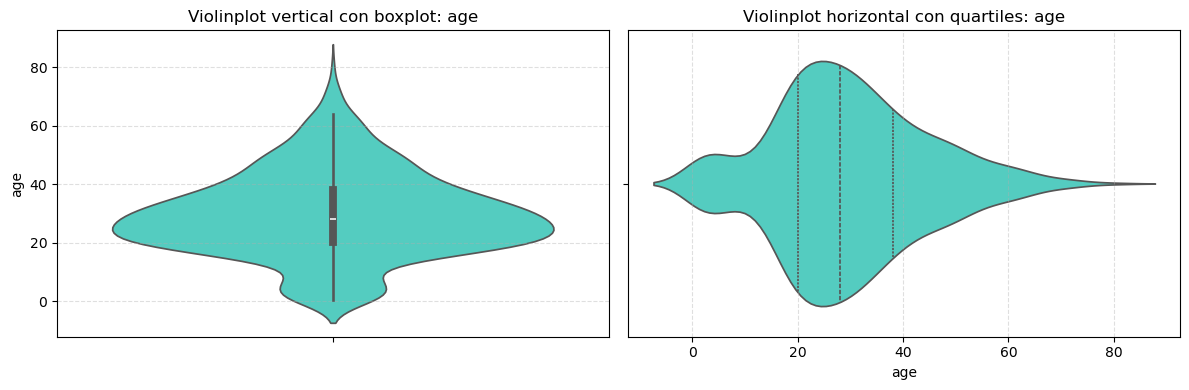

In [213]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Vertical
sns.violinplot(data=titanic_df, y='age', color='turquoise', inner='box', ax=axes[0])
axes[0].set_title('Violinplot vertical con boxplot: age')
axes[0].grid(axis='y', ls='--', alpha=0.4)

# Horizontal
sns.violinplot(data=titanic_df, x='age', color='turquoise', inner='quart', ax=axes[1])
axes[1].set_title('Violinplot horizontal con quartiles: age')
axes[1].grid(axis='x', ls='--', alpha=0.4)

plt.tight_layout()
plt.show()

### 1.6. Medidas de forma: skewness (asimetría) y curtosis
<hr style="border:1px solid gray">


In [214]:
# Con Pandas 
print(f"Asímetría de la variable 'age' (Pandas): {titanic_df['age'].skew():.4f}")
print(f"Curtosis de la variable 'age' (Pandas): {titanic_df['age'].kurtosis():.4f}")

Asímetría de la variable 'age' (Pandas): 0.3891
Curtosis de la variable 'age' (Pandas): 0.1783


In [215]:
# Con Scipy
print(f"Asimetría de la variable 'age' (Scipy): {st.skew(titanic_df['age'].dropna()):.4f}")
print(f"Curtosis de la variable 'age' (Scipy): {st.kurtosis(titanic_df['age'].dropna()):.4f}")

Asimetría de la variable 'age' (Scipy): 0.3883
Curtosis de la variable 'age' (Scipy): 0.1686


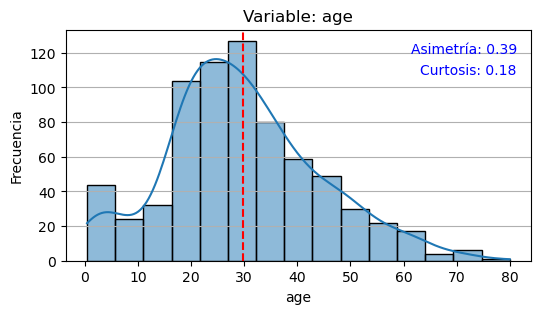

In [216]:
plot_histograma(titanic_df, 'age', mvd= False, snk=True)

### 1.7. Estadística descriptiva completa 
<hr style="border:1px solid gray">


In [217]:
# Con Pandas
print("Estadística descriptiva del dataset Titanic:\n")
titanic_df.describe()

Estadística descriptiva del dataset Titanic:



,age,sibsp,parch,fare
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,0.523008,0.381594,32.204208
std,14.526497,1.102743,0.806057,49.693429
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,0.000000,0.000000,7.910400
50%,28.000000,0.000000,0.000000,14.454200
75%,38.000000,1.000000,0.000000,31.000000
max,80.000000,8.000000,6.000000,512.329200


In [218]:
# estadística básica + percentiles
titanic_df.describe(percentiles=[.1,.9,.95])

,age,sibsp,parch,fare
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,0.523008,0.381594,32.204208
std,14.526497,1.102743,0.806057,49.693429
min,0.420000,0.000000,0.000000,0.000000
10%,14.000000,0.000000,0.000000,7.550000
50%,28.000000,0.000000,0.000000,14.454200
90%,50.000000,1.000000,2.000000,77.958300
95%,56.000000,3.000000,2.000000,112.079150
max,80.000000,8.000000,6.000000,512.329200


In [219]:
# Con Scipy

# Scipy scipy.stats.describe devuelve un objeto con estadísticas descriptivas
ed_titanic = st.describe(titanic_df[['age', 'fare', 'sibsp', 'parch']].dropna())

ed_titanic_df = pd.DataFrame({  
    'Observaciones': ed_titanic.nobs,
    'Min': ed_titanic.minmax[0],
    'Max': ed_titanic.minmax[1],
    'Media': ed_titanic.mean,
    'Varianza': ed_titanic.variance,
    'Asimetría': ed_titanic.skewness,
    'Curtosis': ed_titanic.kurtosis}, index=titanic_df[['age', 'fare', 'sibsp', 'parch']].columns)

ed_titanic_df.head()


,Observaciones,Min,Max,Media,Varianza,Asimetría,Curtosis
age,714,0.42,80.0000,29.699118,211.019125,0.388290,0.168637
fare,714,0.00,512.3292,34.694514,2800.413100,4.643848,30.699725
sibsp,714,0.00,5.0000,0.512605,0.864497,2.514280,6.987321
parch,714,0.00,6.0000,0.431373,0.728103,2.613409,8.782859


---
### 2. Exploración de VARIABLES CATEGÓRICAS



#### 2.1. Vemos frecuencias y categorías

In [220]:
# Variable 'who'
print_categorias(titanic_df, 'who')

Cantidad de categorías que tiene la variable 'who': 3

Nombres de categorías presentes en la variable 'who': ['man', 'woman', 'child']
Categories (3, object): ['child', 'man', 'woman']

Frecuencias de cada categoría en la variable 'who':
       Frecuencia absoluta  Frecuencia relativa (%)
who                                                
man                    537                    60.27
woman                  271                    30.42
child                   83                     9.32



In [221]:
# Variable 'embarked_town'
print_categorias(titanic_df, 'embark_town')

Cantidad de categorías que tiene la variable 'embark_town': 3

Nombres de categorías presentes en la variable 'embark_town': ['Southampton', 'Cherbourg', 'Queenstown', NaN]
Categories (3, object): ['Cherbourg', 'Queenstown', 'Southampton']

Frecuencias de cada categoría en la variable 'embark_town':
             Frecuencia absoluta  Frecuencia relativa (%)
embark_town                                              
Southampton                  644                    72.44
Cherbourg                    168                    18.90
Queenstown                    77                     8.66



In [222]:
# Variable 'class'
print_categorias(titanic_df, 'class')

Cantidad de categorías que tiene la variable 'class': 3

Nombres de categorías presentes en la variable 'class': ['Third', 'First', 'Second']
Categories (3, object): ['First' < 'Second' < 'Third']

Frecuencias de cada categoría en la variable 'class':
        Frecuencia absoluta  Frecuencia relativa (%)
class                                               
Third                   491                    55.11
First                   216                    24.24
Second                  184                    20.65



#### 2.2. Descripción de categóricas con la función $\texttt{describe}$

In [223]:
titanic_df.describe(include='category')

# count = cant. de datos no nulos
# unique = cantidad de categorias distintas
# top = categoria con mayor frecuencia
# freq = frecuencia de la categoria top
# CUIDADO! en el caso multimodal, pandas elige y muestra una categoría arbitrariamente 

,survived,pclass,sex,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891,891,891,889,891,891,891,203,889,891,891
unique,2,3,2,3,3,3,2,7,3,2,2
top,0,3,male,S,Third,man,True,C,Southampton,no,True
freq,549,491,577,644,491,537,537,59,644,549,537


#### 2.3. Visualizaciones para categóricas

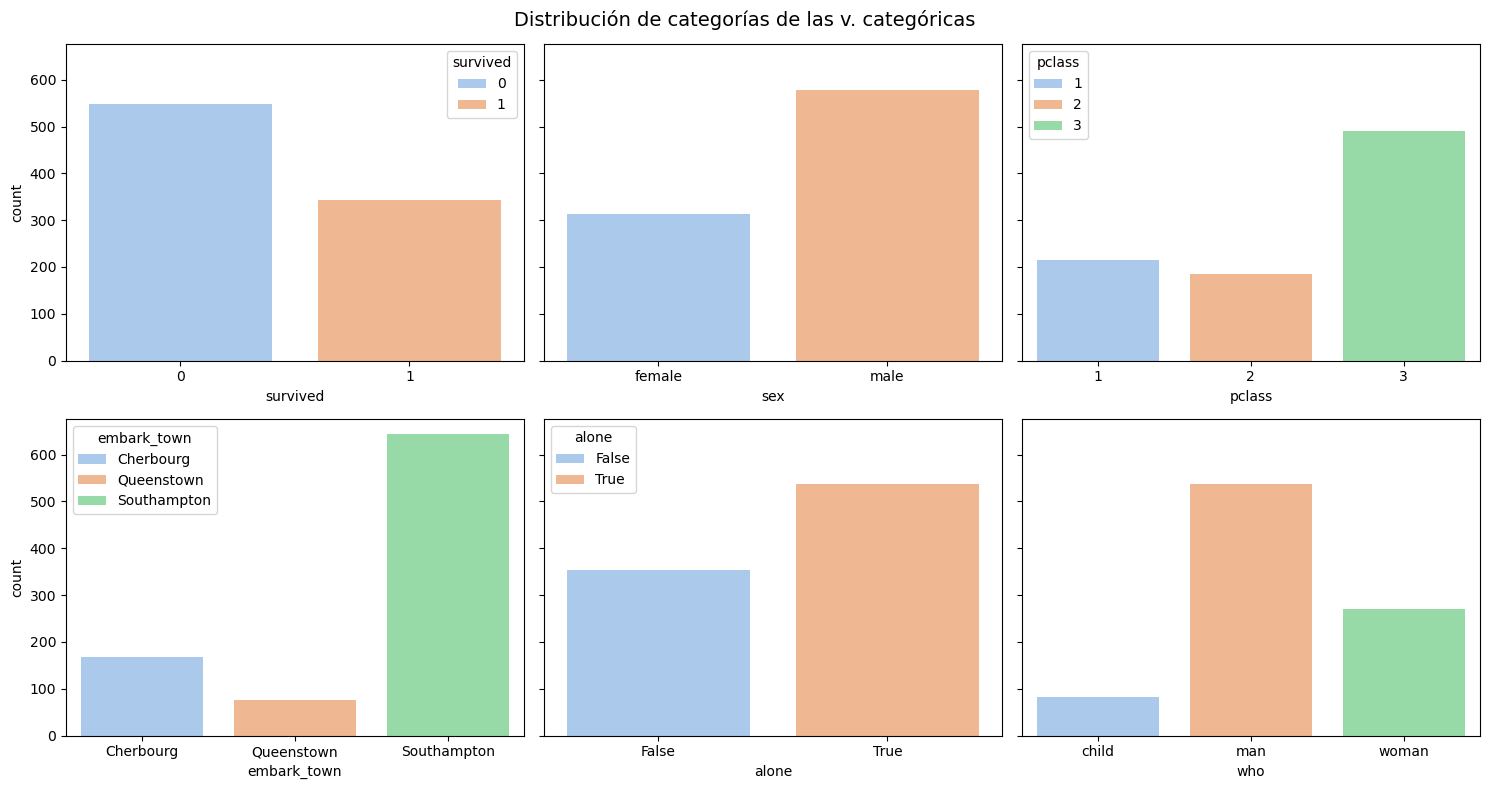

In [224]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
axes = axes.flatten()  

for i, col in enumerate(['survived', 'sex', 'pclass', 'embark_town', 'alone', 'who']):
    sns.countplot(x=col, data=titanic_df, hue=col, palette='pastel', ax=axes[i])

plt.suptitle('Distribución de categorías de las v. categóricas', fontsize=14)
plt.tight_layout()
plt.show()

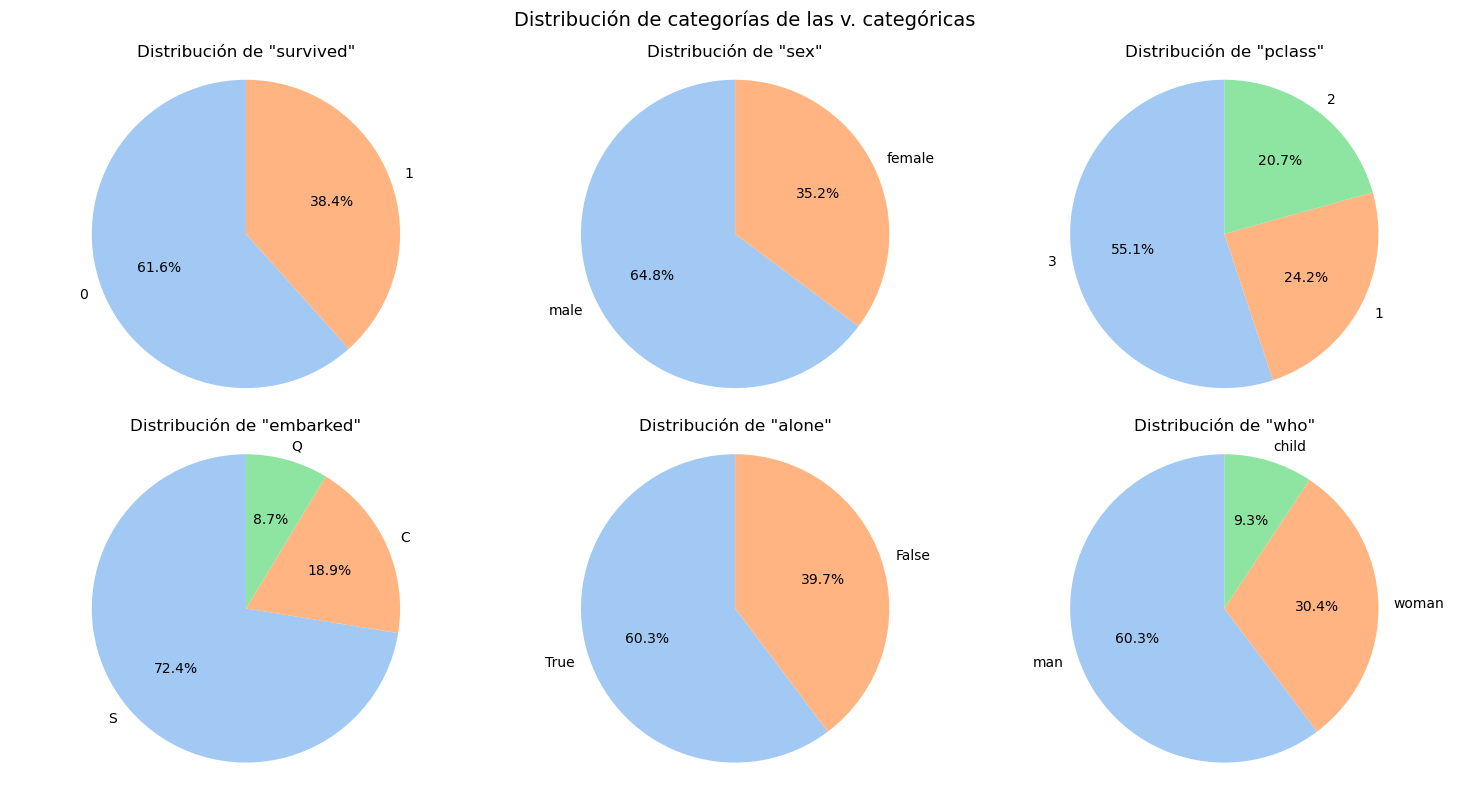

In [225]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten() 

for i, col in enumerate(['survived', 'sex', 'pclass', 'embarked', 'alone', 'who']):
    plot_pie(titanic_df, col, ax=axes[i])


plt.suptitle('Distribución de categorías de las v. categóricas', fontsize=14)
plt.tight_layout()
plt.show()

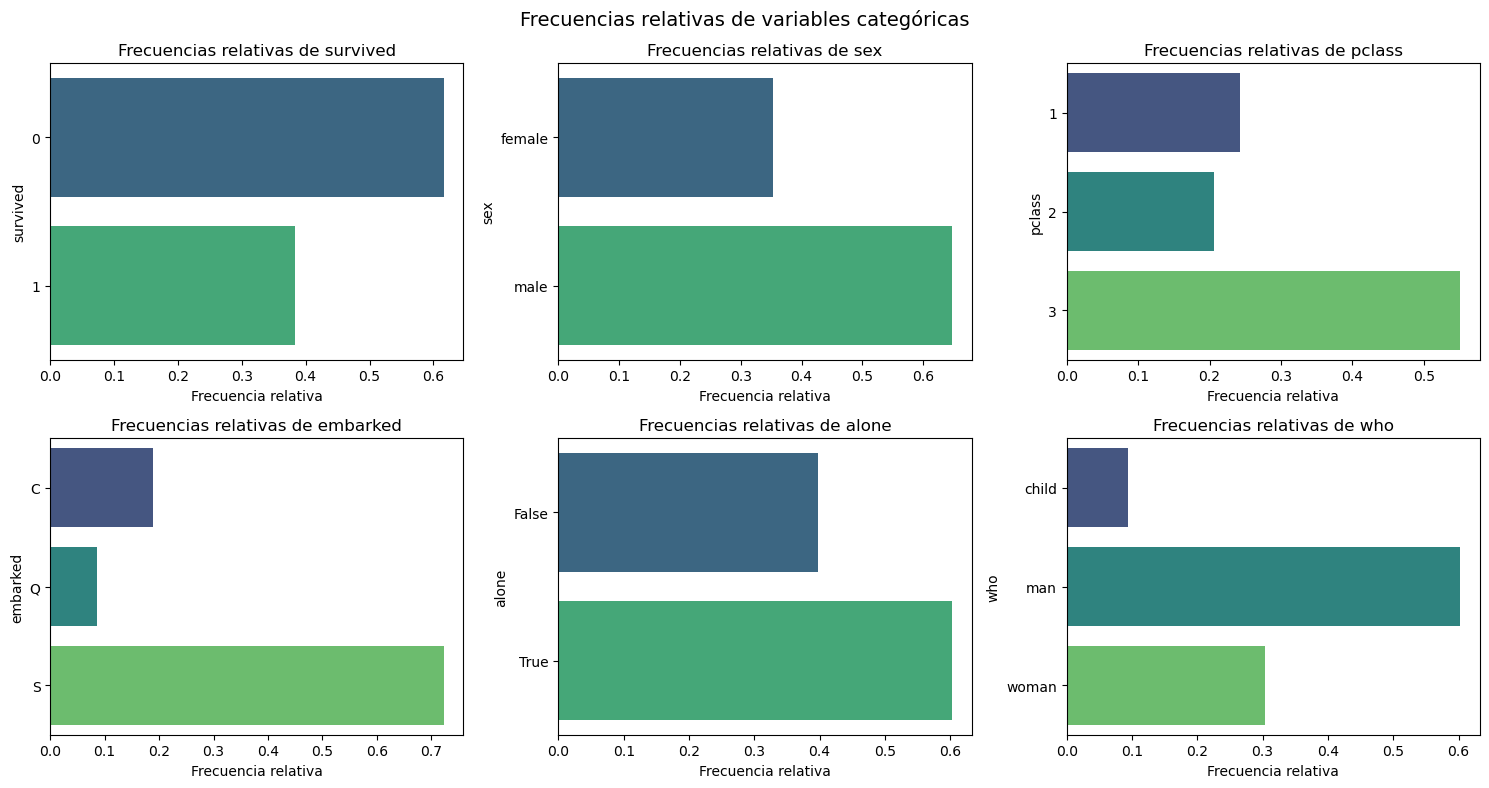

In [226]:

# Plots de frecuencias relativas
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(['survived', 'sex', 'pclass', 'embarked', 'alone', 'who']):
    plot_frecuencias_relativas(titanic_df, col, ax=axes[i])

plt.suptitle('Frecuencias relativas de variables categóricas', fontsize=14)
plt.tight_layout()
plt.show()

---
### 3. Relaciones entre variables

#### 3.1. Numérica-numérica

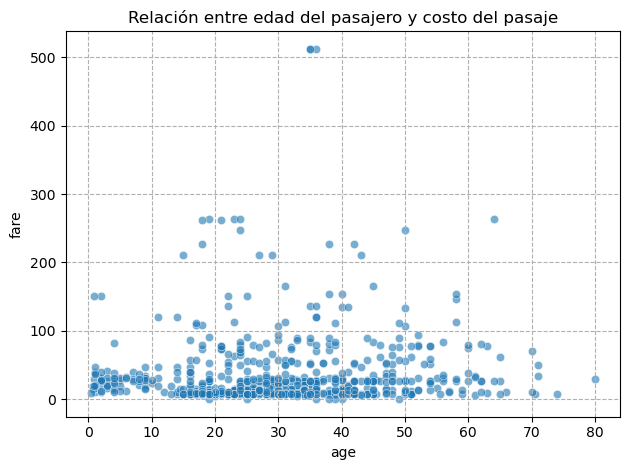

In [227]:
sns.scatterplot(data=titanic_df, x='age', y='fare', alpha=0.6)
plt.grid(ls='--')
plt.title('Relación entre edad del pasajero y costo del pasaje')
plt.tight_layout()
plt.show()

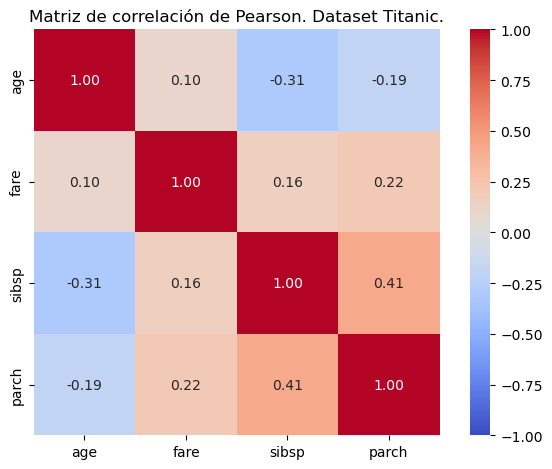

In [228]:
# Opción 1: mostrar toda la matriz de correlación como sale
corr_matrix = titanic_df[titanic_numericas].corr()

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, square=True)
plt.title('Matriz de correlación de Pearson. Dataset Titanic.')
plt.tight_layout()
plt.show()

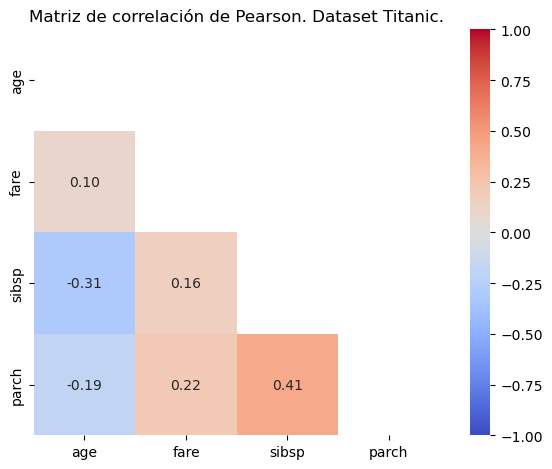

In [229]:
# Opción 2: si no queremos ver información redundante

# Creamos una máscara para ocultar la mitad superior de la matriz
mascara = np.triu(np.ones_like(corr_matrix, dtype=bool)) 

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True, mask=mascara) # Se filtra aplicando una máscara
plt.title('Matriz de correlación de Pearson. Dataset Titanic.')
plt.tight_layout()
plt.show()

#### 3.2. Categórica-categórica

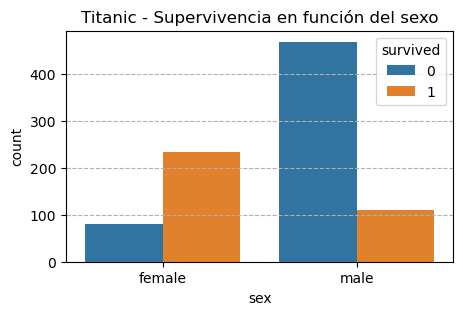

In [230]:
# Cuántas personas sobrevivieron de cada sexo?
plt.figure(figsize=(5, 3))
sns.countplot(x='sex', hue='survived', data=titanic_df)
plt.grid(ls='--', axis='y')
plt.title("Titanic - Supervivencia en función del sexo")
plt.show()

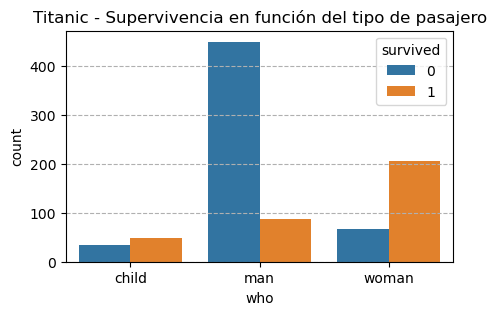

In [231]:
# Cuántas personas sobrevivieron de tipo de pasajero?
plt.figure(figsize=(5, 3))
sns.countplot(x='who', hue='survived', data=titanic_df)
plt.grid(ls='--', axis='y')
plt.title("Titanic - Supervivencia en función del tipo de pasajero")
plt.show()

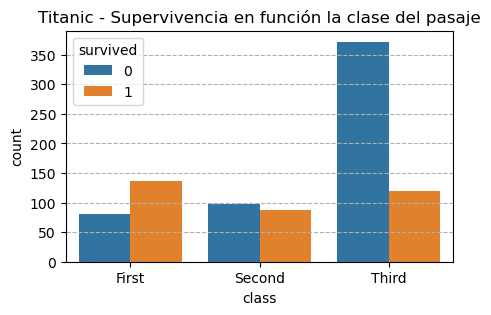

In [232]:
# Cómo se relaciona la supervivencia con la clase del pasaje?
plt.figure(figsize=(5, 3))
sns.countplot(x='class', hue='survived', data=titanic_df)
plt.grid(ls='--', axis='y')
plt.title("Titanic - Supervivencia en función la clase del pasaje")
plt.show()

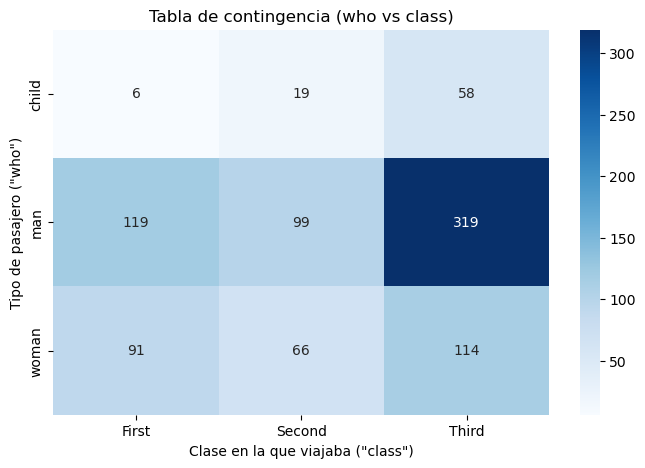

In [233]:
plt.figure(figsize=(8, 5))
cross_tab = pd.crosstab(titanic_df['who'], titanic_df['class'])
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title('Tabla de contingencia (who vs class)')
plt.xlabel('Clase en la que viajaba ("class")')
plt.ylabel('Tipo de pasajero ("who")')
plt.show()

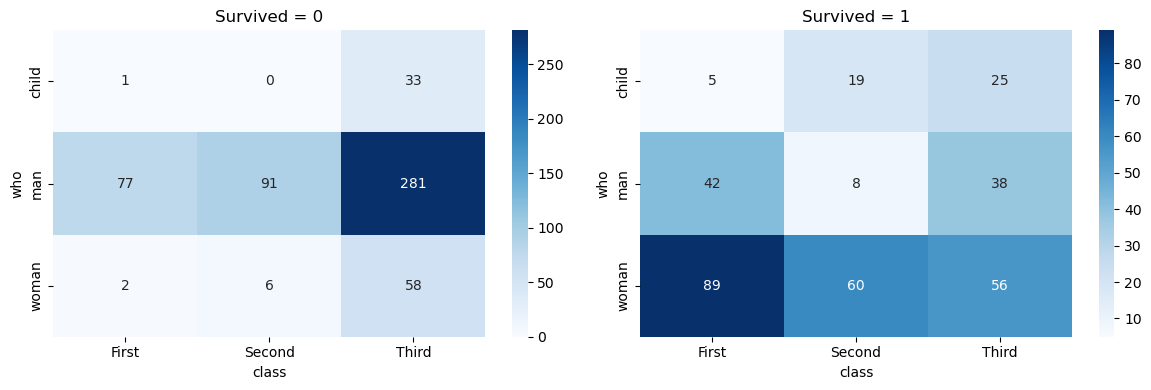

In [234]:
cross_tab = pd.crosstab(titanic_df['who'], [titanic_df['survived'], titanic_df['class']])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, surv in enumerate([0, 1]):
    sns.heatmap(cross_tab[surv], annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Survived = {surv}')

plt.tight_layout()
plt.show()

Problema: no sabemos qué porcentaje del total representan estos números.

Otra opción: Tabla de contingencia normalizada

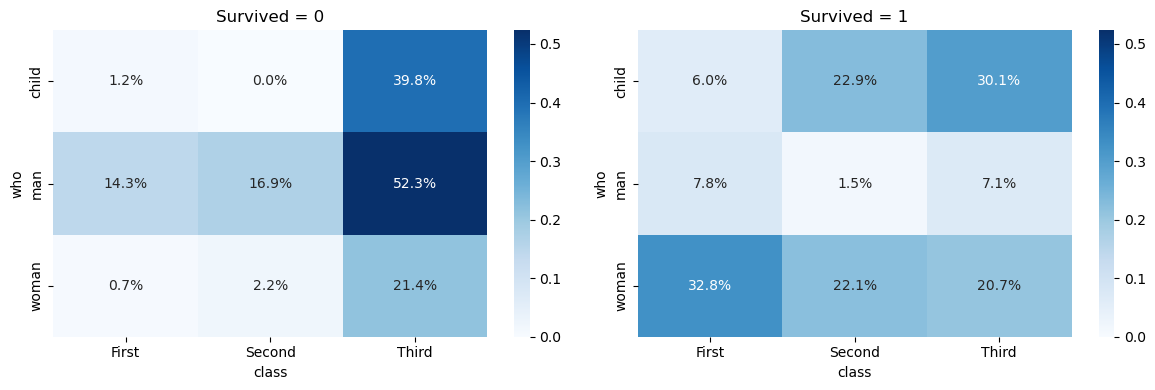

In [235]:
cross_tab_pct = pd.crosstab(titanic_df['who'], [titanic_df['survived'], titanic_df['class']], 
                             normalize='index')  # normalizar por filas para obtener porcentajes dentro de cada tipo de pasajero

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, surv in enumerate([0, 1]):
    sns.heatmap(cross_tab_pct[surv], annot=True, fmt='.1%', cmap='Blues', ax=axes[i],
                vmin=0, vmax=cross_tab_pct.values.max())  # trabajar sobre la misma escala
    axes[i].set_title(f'Survived = {surv}')

plt.tight_layout()
plt.show()

#### 3.3. Numéricas-categóricas

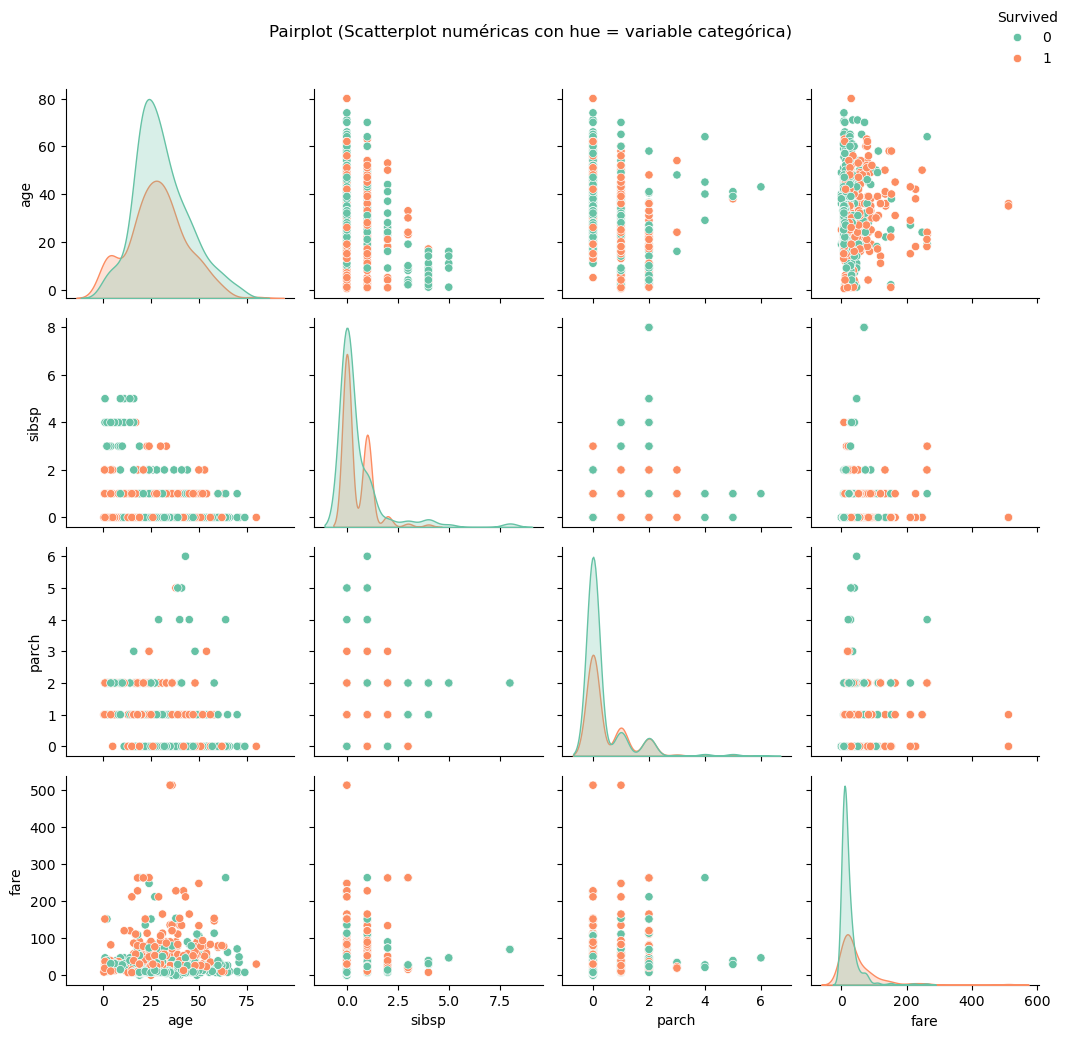

In [236]:
grafico = sns.pairplot(data=titanic_df, hue='survived', palette='Set2')
grafico.figure.suptitle('Pairplot (Scatterplot numéricas con hue = variable categórica)', y=1.02) # Hago todo esto para que me muestre el título del gráfico, porque con pairplot no funciona plt.title()

grafico.legend.set_bbox_to_anchor((1, 1))
grafico.legend.set_title('Survived')

plt.tight_layout()
plt.show()

#### Boxplots y violinplots

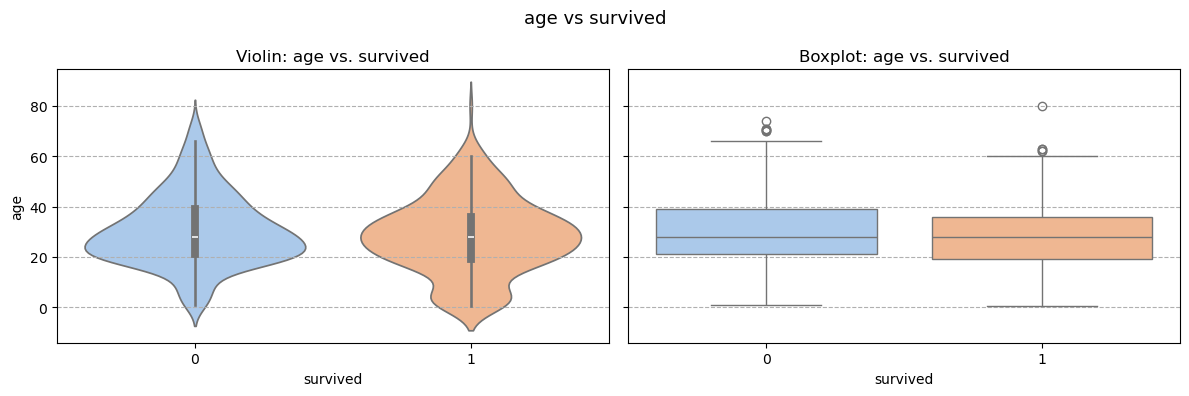

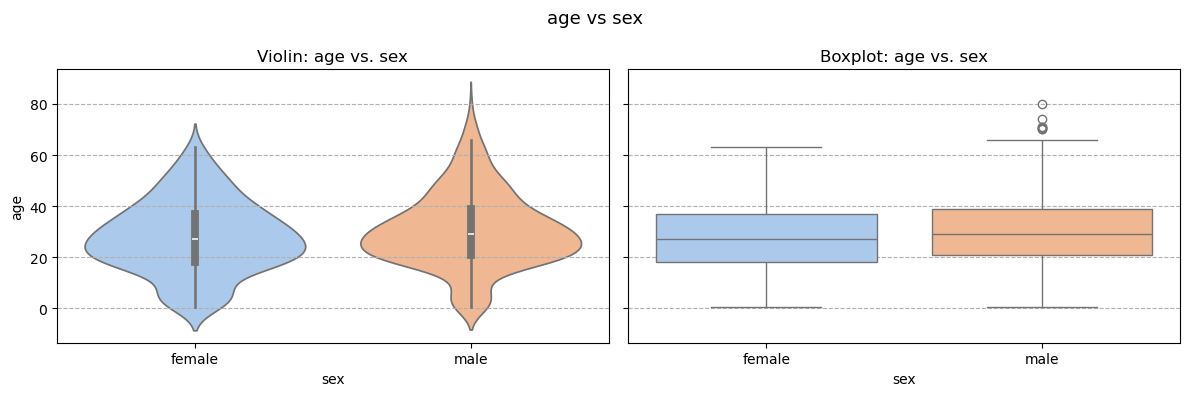

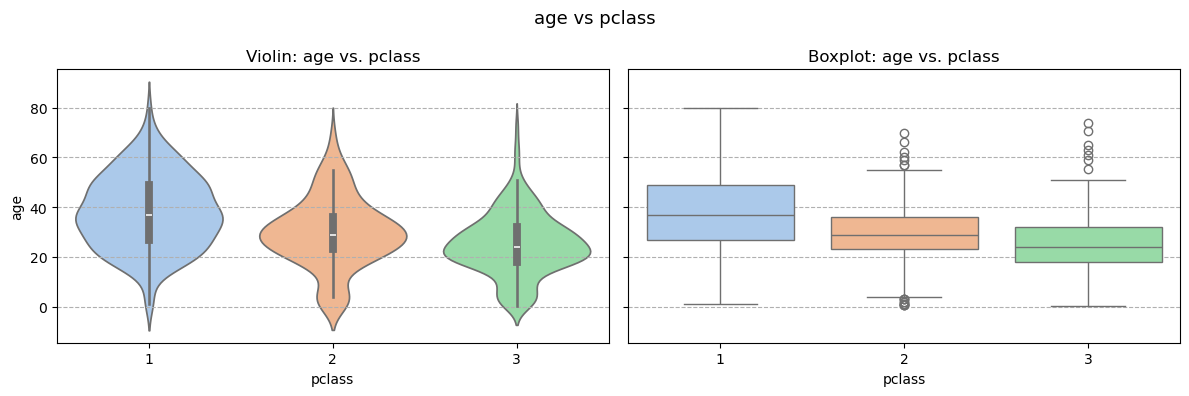

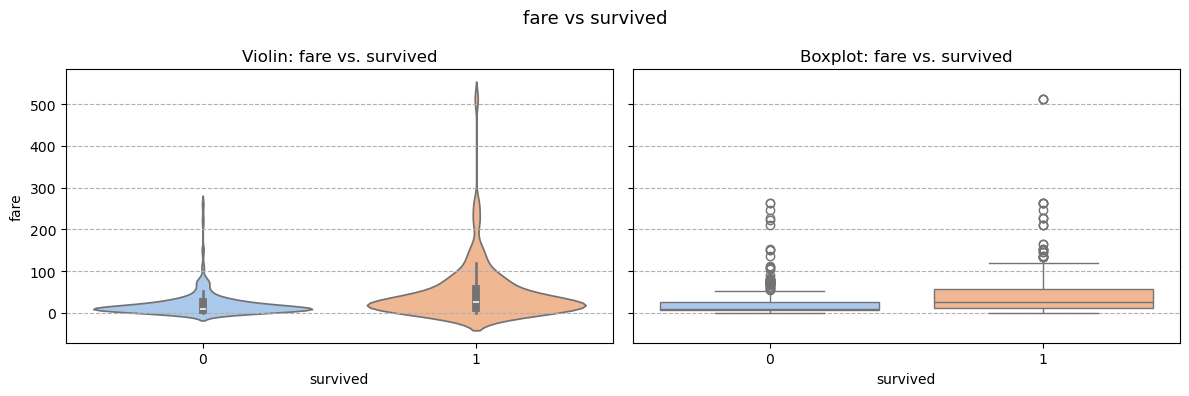

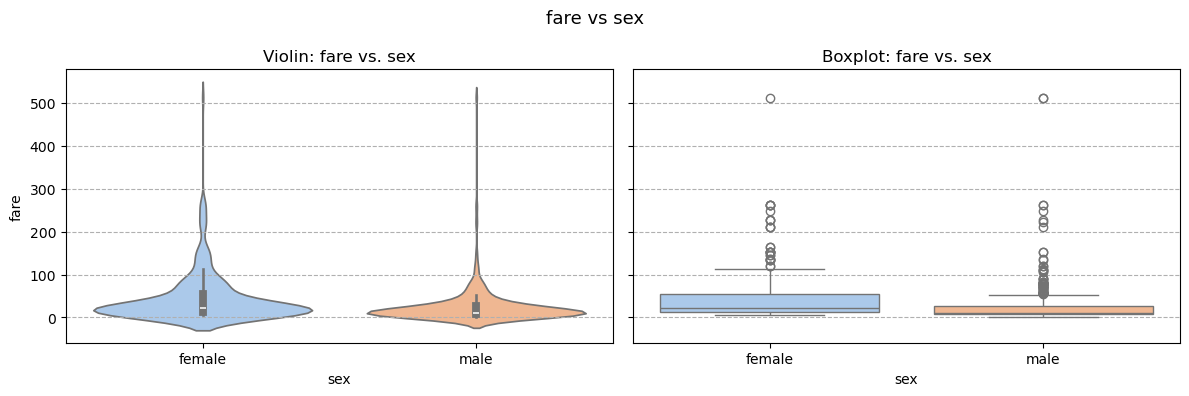

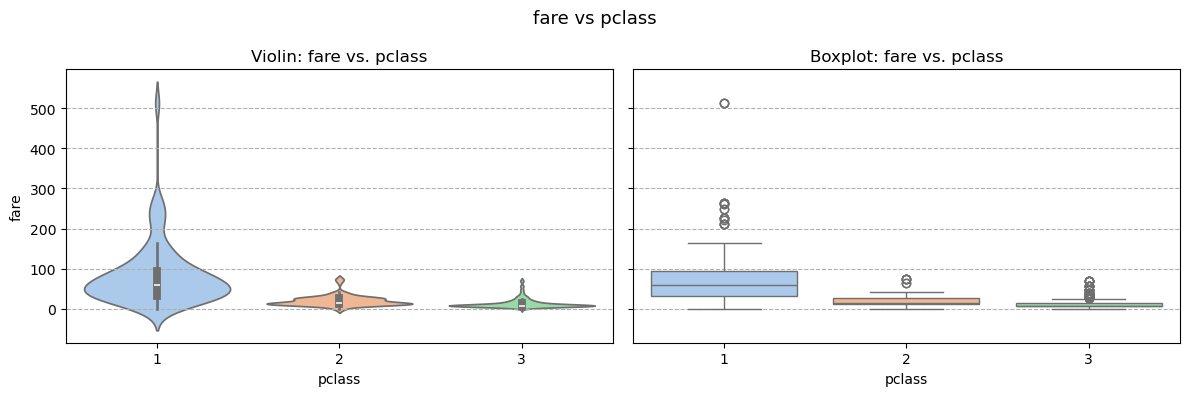

In [237]:
cat_cols = ['survived', 'sex', 'pclass']

for num in ['age', 'fare']:
    for cat in cat_cols:
        plot_violin_box(titanic_df, num, cat)

#### Stripplot

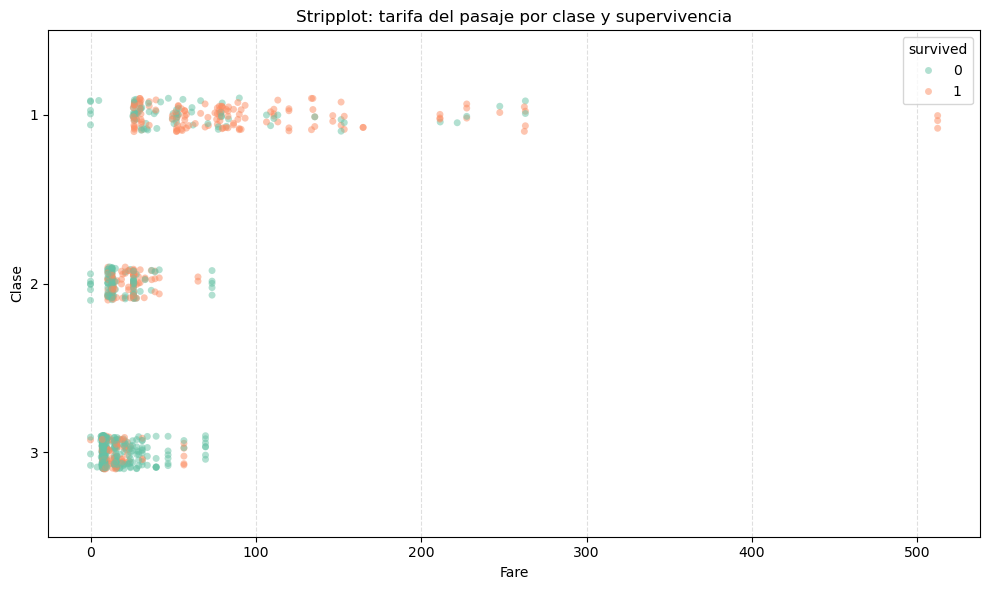

In [238]:
plt.figure(figsize=(10, 6))
sns.stripplot(data=titanic_df, x='fare', y='pclass', 
              hue='survived', palette='Set2', alpha=0.5, size=5, jitter=True)

plt.title('Stripplot: tarifa del pasaje por clase y supervivencia')
plt.xlabel('Fare')
plt.ylabel('Clase')
plt.grid(axis='x', ls='--', alpha=0.4)

plt.tight_layout()
plt.show()

El stripplot dispersa los puntos en forma aleatoria en la dirección vertical (la posición en el eje $\texttt{y}$ no significa nada).

#### Swarmplot

/home/brian/ceia/analisis_de_datos/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 45.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/brian/ceia/analisis_de_datos/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 67.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/brian/ceia/analisis_de_datos/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 8.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/brian/ceia/analisis_de_datos/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 48.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarnin

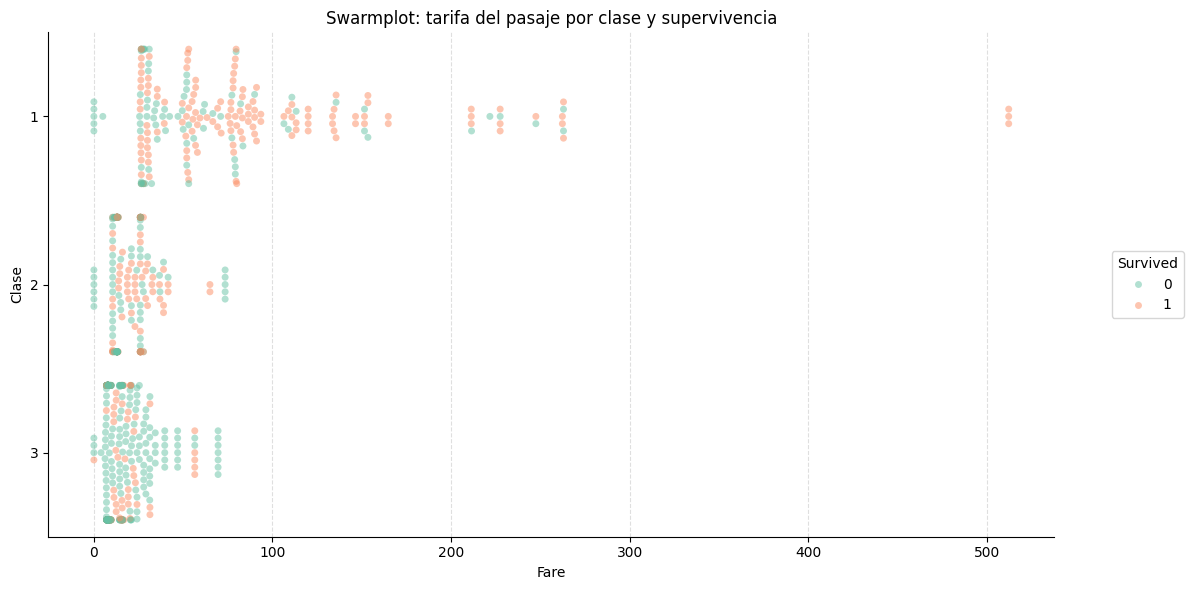

In [29]:
plt.figure(figsize=(12, 6))
sns.swarmplot(data=titanic_df, x='fare', y='pclass', 
              hue='survived', palette='Set2', alpha=0.5, size=5)

plt.title('Swarmplot: tarifa del pasaje por clase y supervivencia')
plt.xlabel('Fare')
plt.ylabel('Clase')
plt.grid(axis='x', ls='--', alpha=0.4)
sns.despine()
plt.legend(title='Survived', bbox_to_anchor=(1.05, 0.5), loc='center left')

plt.tight_layout()
plt.show()

En el swarmplot, se distribuyen los puntos en forma vertical de manera que nunca se superpongan. En general resulta más legible que el stripplot, pero es más lento.